In [1]:
import sys, os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

print("✅ Project root:", ROOT)

✅ Project root: c:\Users\aayus\OneDrive\Desktop\software-defect-prediction-research


In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from imblearn.over_sampling import SMOTE, ADASYN

from src.models.hybrid_model.hybrid_architecture import HybridModel

In [3]:
def load_data(sample_size=12000):
    paths = [
        "data/processed/encoded.pkl",
        "../data/processed/encoded.pkl"
    ]

    for p in paths:
        if os.path.exists(p):
            print(f"✅ Loaded from {p}")
            df = joblib.load(p)
            break
    else:
        raise FileNotFoundError("Run encoding.py first")

    return df.sample(n=min(sample_size, len(df)), random_state=42)

df = load_data()

✅ Loaded from ../data/processed/encoded.pkl


In [4]:
target = "defects"

X = df.drop(columns=[target]).values.astype(np.float32)
y = df[target].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

adasyn = ADASYN(random_state=42)
X_ad, y_ad = adasyn.fit_resample(X_train, y_train)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

def build_cnn(input_shape):
    model = Sequential()

    model.add(Conv1D(32, 3, activation="relu", input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))

    # IMPORTANT: feature layer (used in hybrid)
    model.add(Dense(32, activation="relu", name="feature_layer"))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def train_cnn(X, y):
    X_cnn = X.reshape(X.shape[0], X.shape[1], 1)

    model = build_cnn((X.shape[1], 1))

    early = EarlyStopping(patience=5, restore_best_weights=True)

    history = model.fit(
        X_cnn, y,
        validation_split=0.2,
        epochs=100,
        batch_size=64,
        callbacks=[early],
        verbose=1
    )

    # Accuracy plot
    plt.figure()
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("CNN Accuracy vs Epoch")
    plt.legend()
    plt.show()

    return model

In [7]:
def run_hybrid(X_train, y_train, X_test, name):

    print(f"\n🚀 Running Hybrid: {name}")

    # Train CNN
    cnn = train_cnn(X_train, y_train)

    # Hybrid model
    hybrid = HybridModel(cnn)

    # Train hybrid
    hybrid.fit(X_train, y_train)

    # Predict
    preds = hybrid.predict(X_test)

    return hybrid, preds


🚀 Running Hybrid: Original


Epoch 1/100


120/120 [==============================] - 2s 8ms/step - loss: 1.6490 - accuracy: 0.9126 - val_loss: 0.1997 - val_accuracy: 0.9380
Epoch 2/100
120/120 [==============================] - 1s 5ms/step - loss: 0.4758 - accuracy: 0.9277 - val_loss: 0.1813 - val_accuracy: 0.9380
Epoch 3/100
120/120 [==============================] - 1s 5ms/step - loss: 0.3631 - accuracy: 0.9322 - val_loss: 0.2233 - val_accuracy: 0.9318
Epoch 4/100
120/120 [==============================] - 0s 4ms/step - loss: 0.2088 - accuracy: 0.9397 - val_loss: 0.1443 - val_accuracy: 0.9417
Epoch 5/100
120/120 [==============================] - 0s 4ms/step - loss: 0.2454 - accuracy: 0.9419 - val_loss: 0.1470 - val_accuracy: 0.9391
Epoch 6/100
120/120 [==============================] - 0s 4ms/step - loss: 0.3579 - accuracy: 0.9353 - val_loss: 0.2942 - val_accuracy: 0.9406
Epoch 7/100
120/120 [==============================] - 0s 4ms/step - loss: 0.2381 - accuracy: 0.9419 - val_los

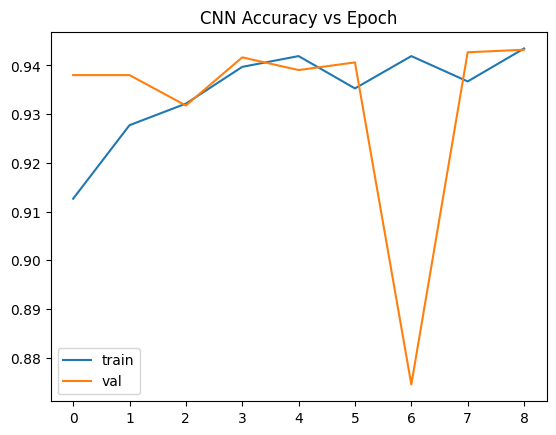

[18:58:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:58:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:58:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




🚀 Running Hybrid: SMOTE
Epoch 1/100
203/203 [==============================] - 2s 5ms/step - loss: 0.7903 - accuracy: 0.8963 - val_loss: 0.6419 - val_accuracy: 0.8121
Epoch 2/100
203/203 [==============================] - 1s 5ms/step - loss: 0.2349 - accuracy: 0.9207 - val_loss: 0.2595 - val_accuracy: 0.8959
Epoch 3/100
203/203 [==============================] - 1s 4ms/step - loss: 0.2132 - accuracy: 0.9294 - val_loss: 0.1881 - val_accuracy: 0.9252
Epoch 4/100
203/203 [==============================] - 1s 4ms/step - loss: 0.1690 - accuracy: 0.9391 - val_loss: 0.0791 - val_accuracy: 0.9957
Epoch 5/100
203/203 [==============================] - 1s 4ms/step - loss: 0.1857 - accuracy: 0.9346 - val_loss: 0.1483 - val_accuracy: 0.9516
Epoch 6/100
203/203 [==============================] - 1s 4ms/step - loss: 0.1699 - accuracy: 0.9432 - val_loss: 0.0973 - val_accuracy: 0.9701
Epoch 7/100
203/203 [==============================] - 1s 4ms/step - loss: 0.1557 - accuracy: 0.9429 - val_loss: 0.12

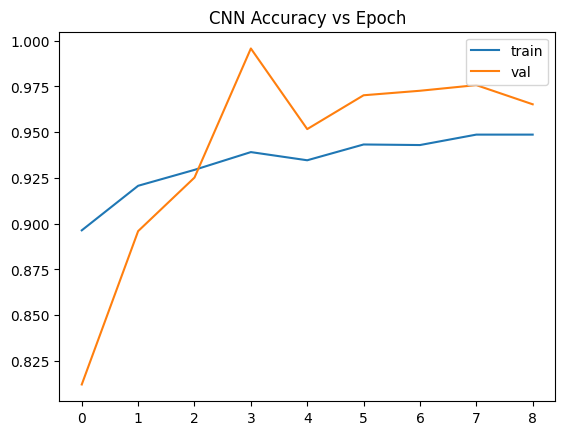

[18:59:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:59:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:59:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:59:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




🚀 Running Hybrid: ADASYN
Epoch 1/100
202/202 [==============================] - 2s 6ms/step - loss: 0.7405 - accuracy: 0.8547 - val_loss: 0.2989 - val_accuracy: 0.9091
Epoch 2/100
202/202 [==============================] - 1s 4ms/step - loss: 0.2310 - accuracy: 0.9134 - val_loss: 0.1839 - val_accuracy: 0.9711
Epoch 3/100
202/202 [==============================] - 1s 4ms/step - loss: 0.2159 - accuracy: 0.9226 - val_loss: 0.1602 - val_accuracy: 0.9510
Epoch 4/100
202/202 [==============================] - 1s 5ms/step - loss: 0.2012 - accuracy: 0.9269 - val_loss: 0.0538 - val_accuracy: 0.9960
Epoch 5/100
202/202 [==============================] - 1s 4ms/step - loss: 0.2668 - accuracy: 0.9200 - val_loss: 0.6571 - val_accuracy: 0.7315
Epoch 6/100
202/202 [==============================] - 1s 4ms/step - loss: 0.1940 - accuracy: 0.9300 - val_loss: 0.5191 - val_accuracy: 0.7942
Epoch 7/100
202/202 [==============================] - 1s 5ms/step - loss: 0.1735 - accuracy: 0.9385 - val_loss: 0.1

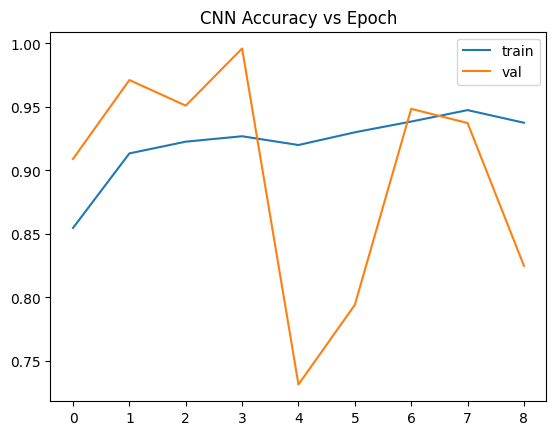

[19:00:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:00:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:00:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:00:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



In [8]:
results = {}
models  = {}

# Original
models["original"], results["original"] = run_hybrid(
    X_train, y_train, X_test, "Original"
)

# SMOTE
models["smote"], results["smote"] = run_hybrid(
    X_sm, y_sm, X_test, "SMOTE"
)

# ADASYN
models["adasyn"], results["adasyn"] = run_hybrid(
    X_ad, y_ad, X_test, "ADASYN"
)

In [9]:
def evaluate(y_true, y_pred, name):
    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()


===== original =====
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       371
           1       0.98      0.96      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.90      0.92      0.91      2400
weighted avg       0.95      0.95      0.95      2400



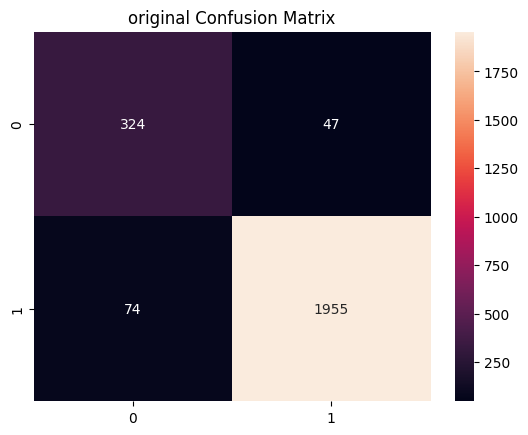


===== smote =====
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       371
           1       0.99      0.96      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.90      0.94      0.92      2400
weighted avg       0.96      0.95      0.96      2400



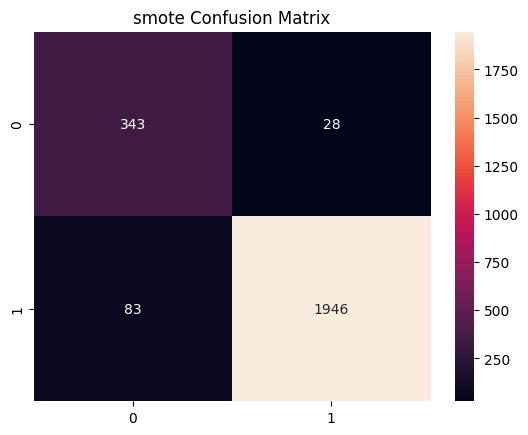


===== adasyn =====
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       371
           1       0.99      0.96      0.97      2029

    accuracy                           0.96      2400
   macro avg       0.90      0.96      0.92      2400
weighted avg       0.96      0.96      0.96      2400



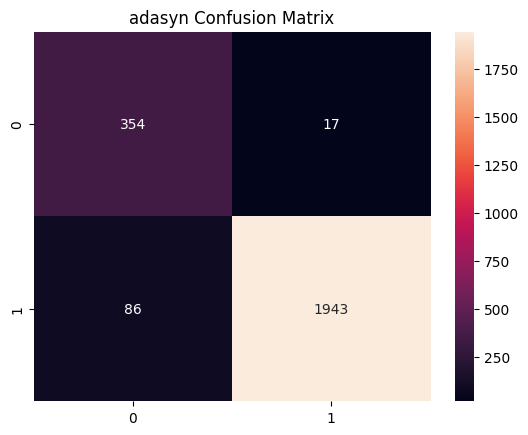

In [10]:
for name, pred in results.items():
    evaluate(y_test, pred, name)

In [11]:
def plot_roc(y_true, y_pred, name):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(name)
    plt.legend()
    plt.show()

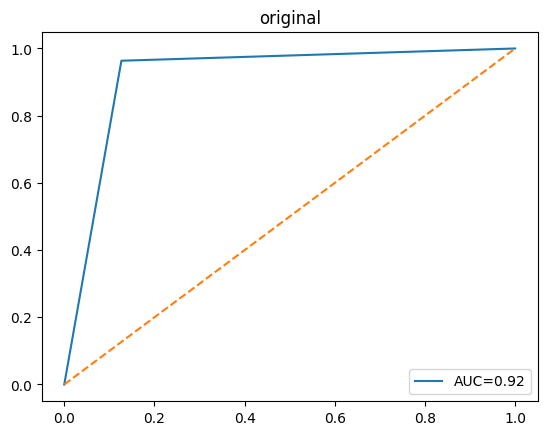

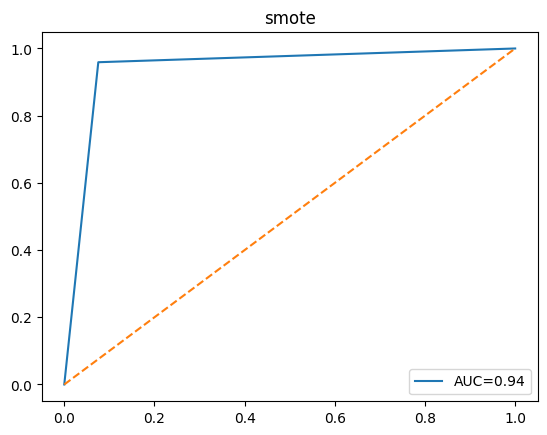

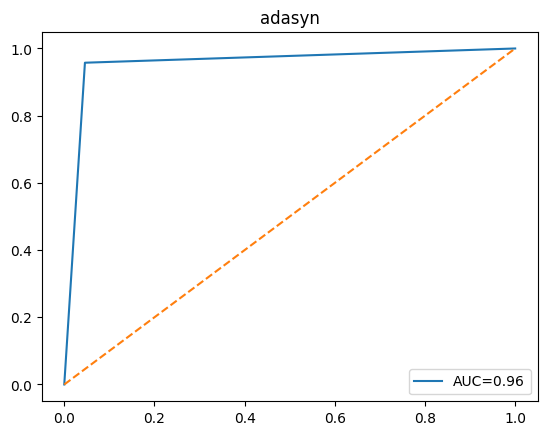

In [12]:
for name, pred in results.items():
    plot_roc(y_test, pred, name)

In [13]:
hybrid = models["original"]

# TRAIN stacking properly
dl_train = hybrid.extract_dl_features(X_train)
X_train_combined = hybrid.combiner.combine(X_train, dl_train)

hybrid.stacking.fit(X_train_combined, y_train)

# TEST
dl_test = hybrid.extract_dl_features(X_test)
X_test_combined = hybrid.combiner.combine(X_test, dl_test)

S_test = hybrid.stacking.predict(X_test_combined)

[19:00:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:00:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[19:00:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



In [14]:
S_sample = S_test[:500]

meta_model = hybrid.meta_model.model

explainer_meta = shap.Explainer(
    meta_model.predict_proba,
    S_sample
)

shap_values_meta = explainer_meta(S_sample)

ExactExplainer explainer: 501it [00:11, 40.08it/s]                          


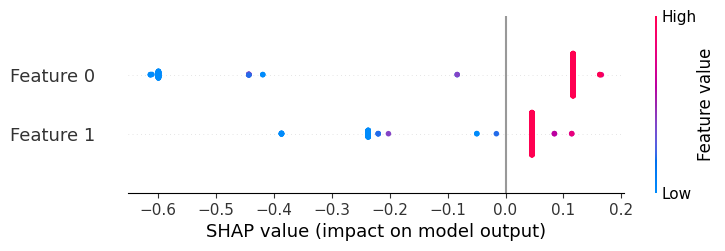

In [15]:
shap.plots.beeswarm(shap_values_meta[:, :, 1])

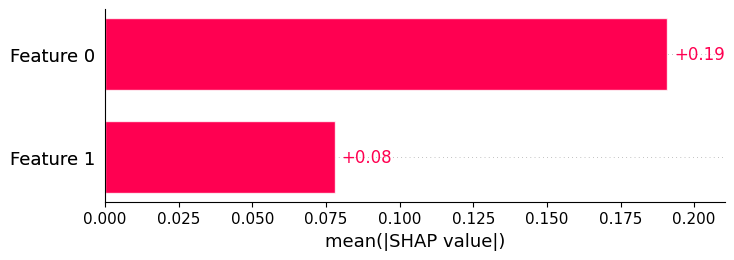

In [16]:
shap.plots.bar(shap_values_meta[:, :, 1])

In [17]:
shap.initjs()

shap.force_plot(
    shap_values_meta.base_values[0, 1],
    shap_values_meta.values[0, :, 1],
    S_sample[0]
)

In [18]:
import shap
import os

os.makedirs("results", exist_ok=True)

plot = shap.force_plot(
    shap_values_meta.base_values[0, 1],
    shap_values_meta.values[0, :, 1],
    S_sample[0]
)

shap.save_html(
    "results/shap_force_plot.html",
    plot,
    full_html=True
)